<a href="https://colab.research.google.com/github/Janhvesh-Patil/RiskLens-AI/blob/main/backend/TransactionFraudDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the Dataset from Kaggle - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [2]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{path}/creditcard.csv")

## Understanding Data

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Here Class 0 = "Not fraud" and 1 = "fraud".
### Features V1, V2, … V28 are the principal components obtained with PCA.
### Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
### The feature 'Amount' is the transaction Amount

In [5]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


### All numeric values, that's great

In [6]:
df.shape

(284807, 31)

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### No Null values, so no data cleaning required in this place

## Visualizing the Data

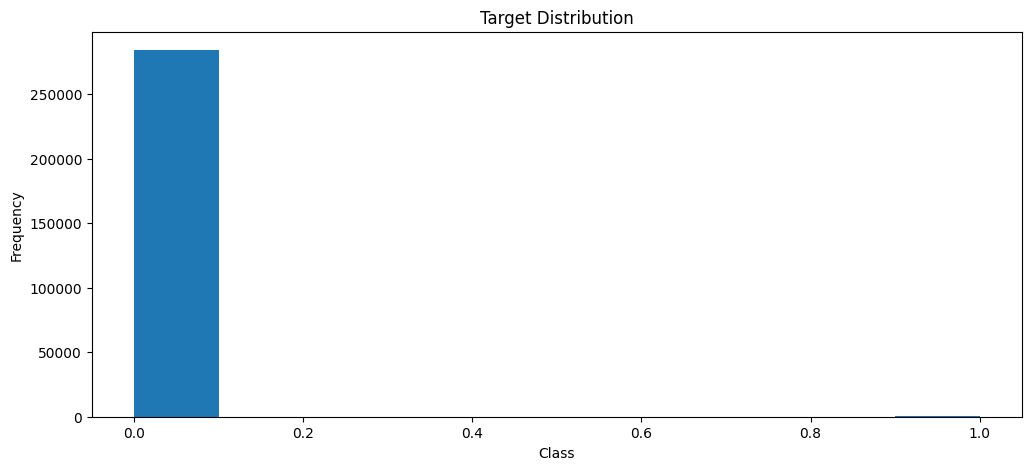

In [9]:
# Target Distribution

targetColumn = df["Class"]

plt.figure(figsize = (12, 5))
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.hist(targetColumn)
plt.show()

### This is massive class imbalance

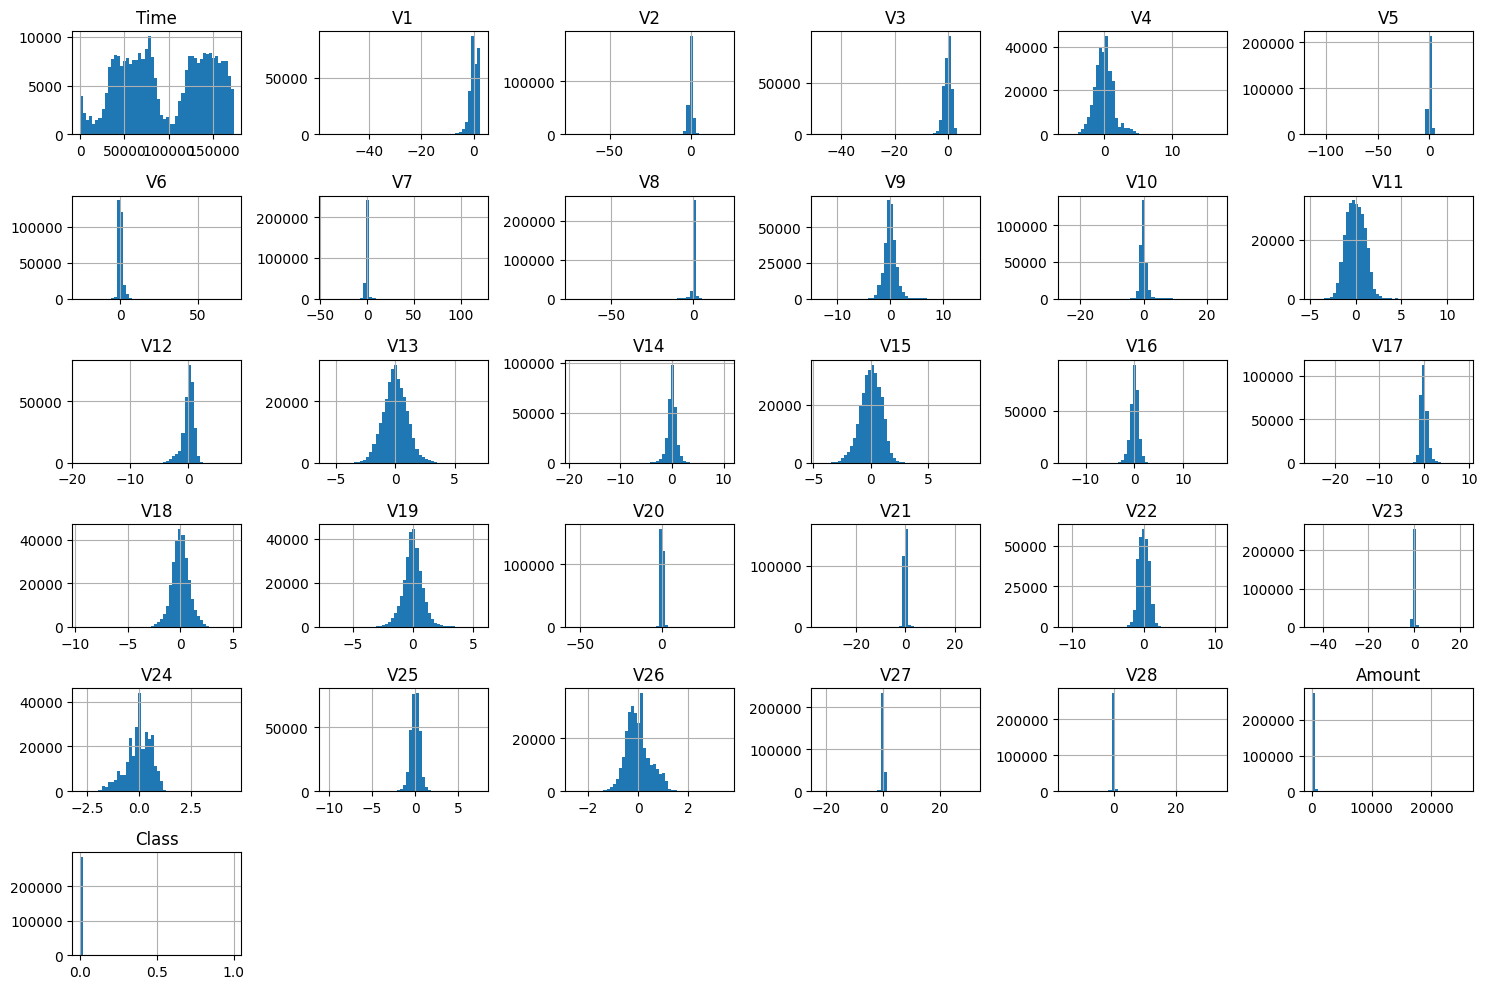

In [10]:
# All the columns distribution

df.hist(figsize = (15, 10), bins = 50)
plt.tight_layout()
plt.show()

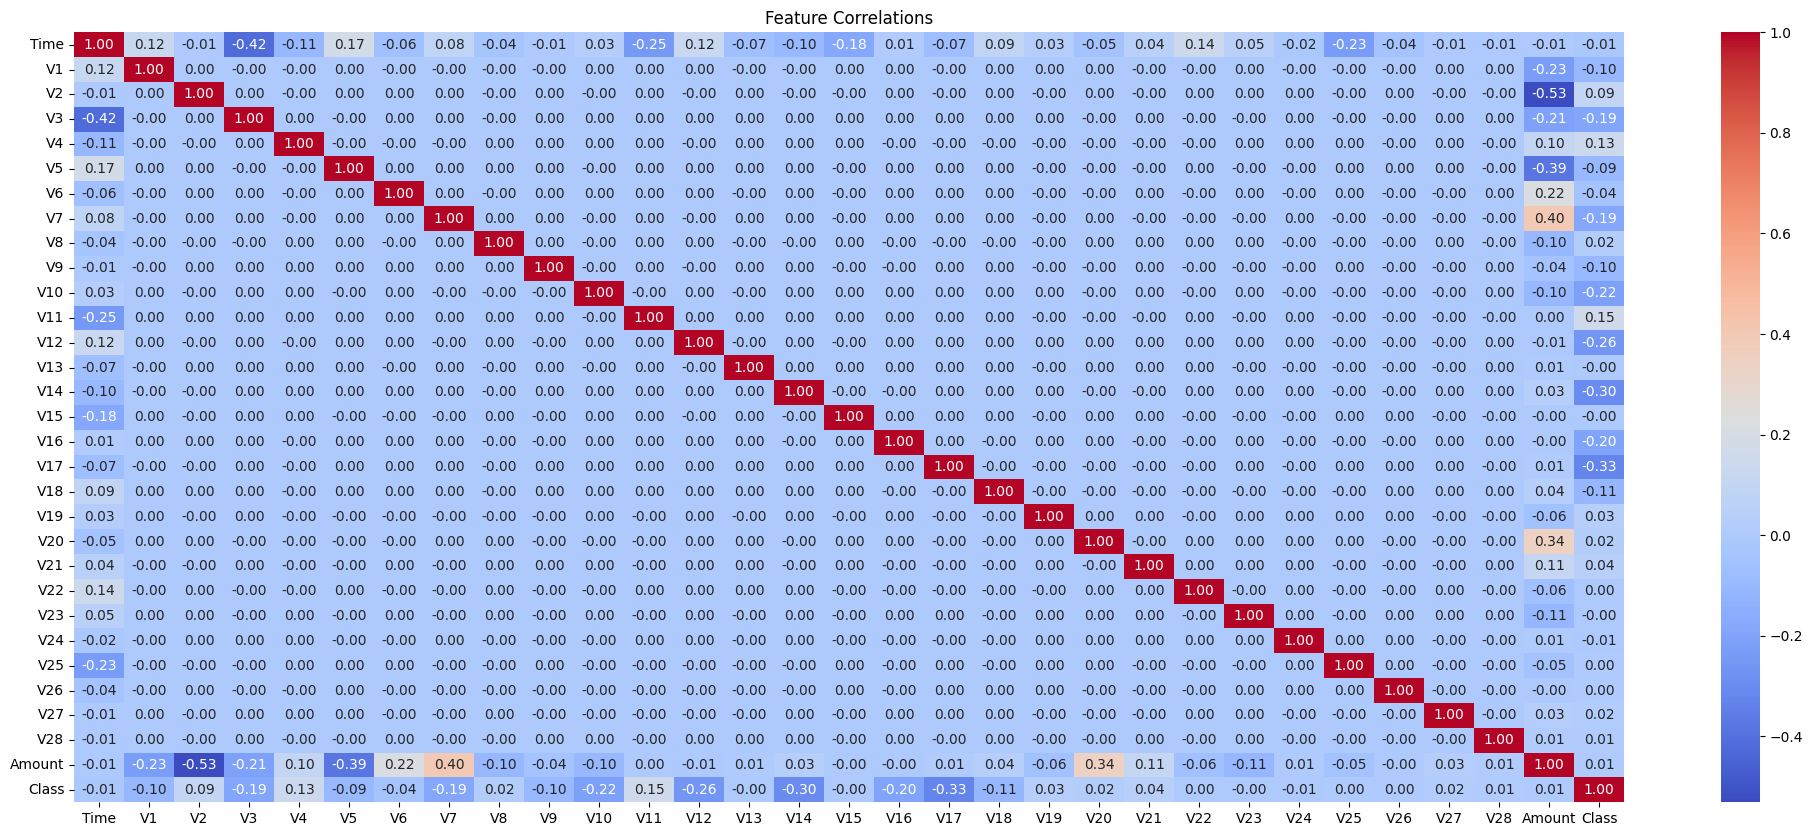

In [11]:
# Finding correlations using heatmap
features = df.columns.tolist()

plt.figure(figsize=(25,10))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

### No highlighting correlations

In [12]:
correlations = df.corr()["Class"].drop("Class")
topFeatures = correlations.abs().nlargest(10).index.tolist()

topFeatures

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

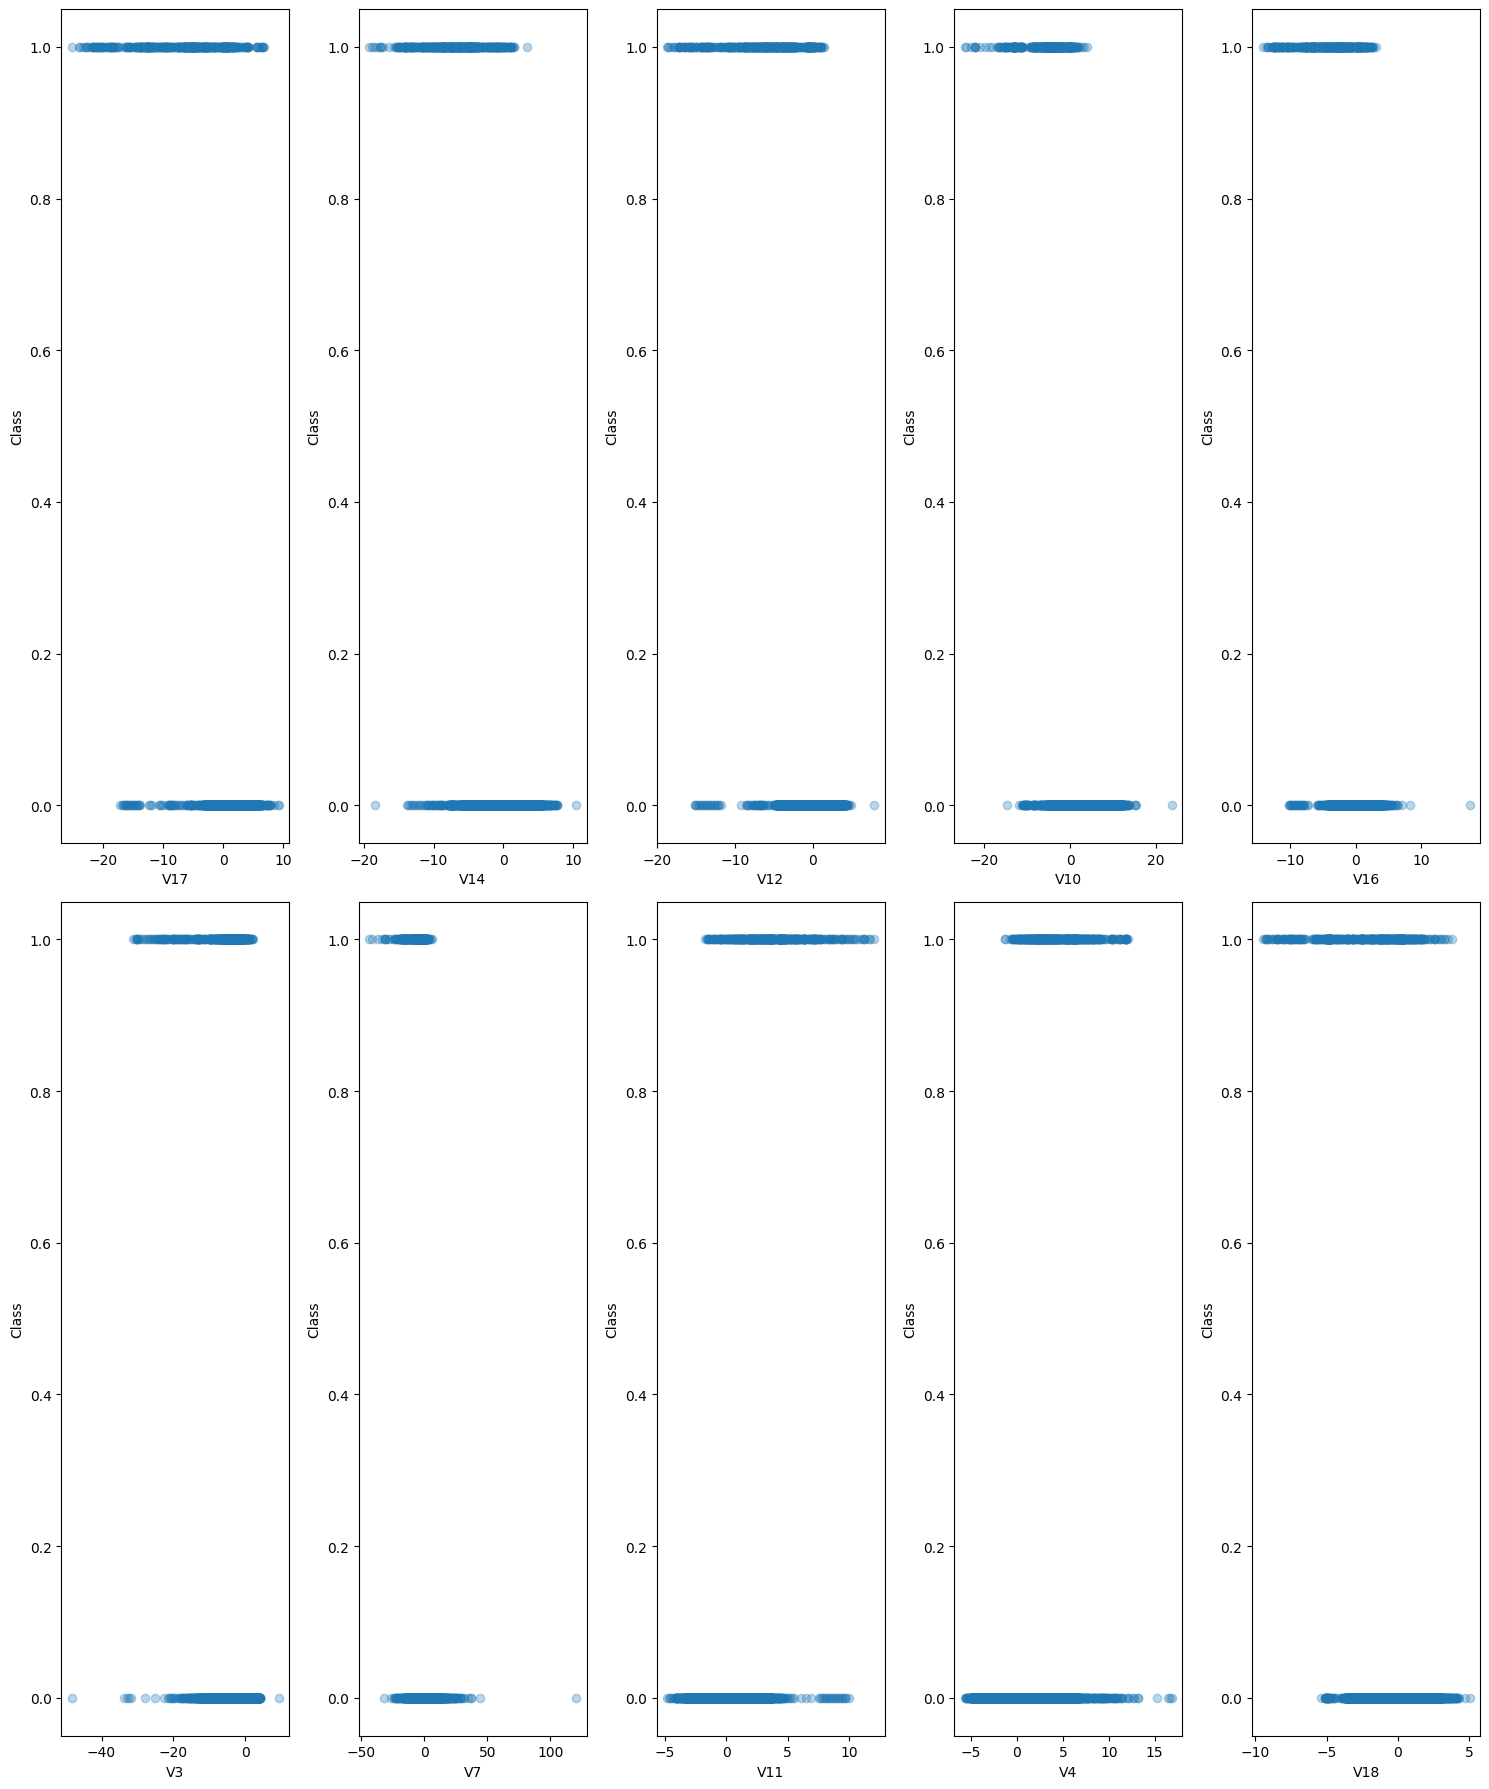

In [13]:
# Scatterplots of top features

fig, axes = plt.subplots(2, 5, figsize=(15,18))
for i, feature in enumerate(topFeatures):
    ax = axes[i//5, i%5]
    ax.scatter(df[feature], df["Class"], alpha=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

### No much helpful.

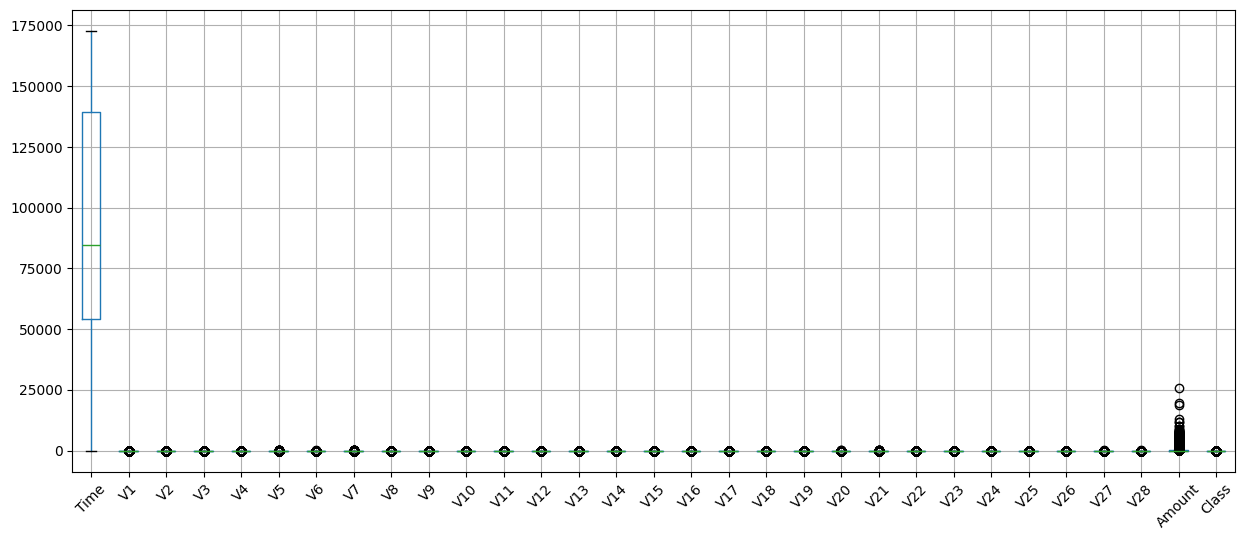

In [14]:
# Boxplots for outlier detection
plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()


### A lot of outliers in Amount feature.

In [15]:
print(f"Fraud rate: {df["Class"].mean():.2%}")
print(f"Class distribution:\n{df["Class"].value_counts()}")

Fraud rate: 0.17%
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


# Data Cleaning

## Need to handle the outliers

In [16]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Lower bound = {lower}")
print(f"Upper bound = {upper}")

outliers = df[
    (df['Amount'] < lower) |
    (df['Amount'] > upper)
]

print(f"Number of outliers = {len(outliers)}")
print(f"Fraud among outliers = {outliers['Class'].sum()}")

Q1 = 5.6
Q3 = 77.16499999999999
IQR = 71.565
Lower bound = -101.7475
Upper bound = 184.5125
Number of outliers = 31904
Fraud among outliers = 91


### Amount is heavily skewed therefore we need to compress it without loosing the values

In [17]:
# Creating a custom transformer to handle this
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class AmountTransformer(BaseEstimator, TransformerMixin):
  def __init__(self):
    return None

  def fit(self, X, y = None):
    return self

  def transform(self, X):
    X = X.copy()
    X["Amount"] = X["Amount"].apply(np.log1p)
    return X

In [18]:
numericPipeLine = Pipeline([
    ("scaler", StandardScaler())
])

In [19]:
amountPipeline = Pipeline([
    ("log", AmountTransformer()),
    ("scale", StandardScaler())
])

# Data Preprocessing

In [20]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("num", numericPipeLine, [c for c in df.columns if c not in ("Amount", "Class")]),
    ("amount", amountPipeline, ["Amount"])
])

In [21]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 1081


In [22]:
print(df[df.duplicated()]['Class'].sum())

19


### Removing these duplicates and reseting the index to not cause data leakeage during train/test split

In [23]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Training the model

In [24]:
from sklearn.linear_model import LogisticRegression

fullPipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("model", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis = 1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [26]:
fullPipeline.fit(X_train, y_train)
lr_predictions = fullPipeline.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy Score: ", accuracy_score(y_test, lr_predictions))
print("Precision Score: ", precision_score(y_test, lr_predictions))
print("Recall Score: ", recall_score(y_test, lr_predictions))
print("F1 Score: ", f1_score(y_test, lr_predictions))


Accuracy Score:  0.9748528530645332
Precision Score:  0.05540720961281709
Recall Score:  0.8736842105263158
F1 Score:  0.10420590081607031


### Confusion Matrix

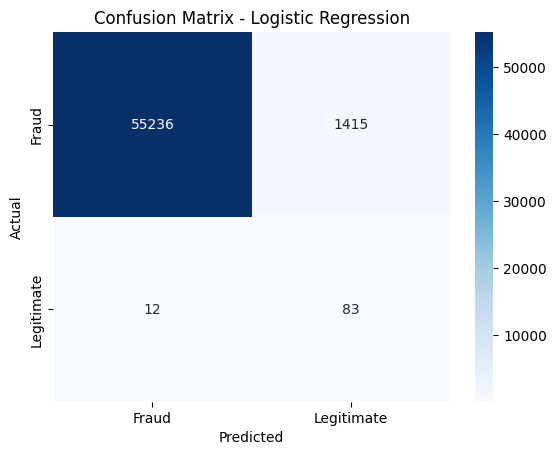

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fraud', 'Legitimate'],
            yticklabels=['Fraud', 'Legitimate'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Precision score of 0.055 -> Of all transactions flagged as fraud, only ~5.5% were truly fraudulent.

### Recall score of 0.874 -> Of all actual fraudulent transactions, the model successfully caught ~87.4%.

### F1 score of 0.104 -> is the balance between precision and recall which is low due to poor precision

### The predict() uses a threshold of 0.5. This led to the huge difference in recall and low precision.

In [29]:
# Get confidence scores (0 to 1) instead of just yes/no answers.
# We need these to test different cutoff points later.

lr_probability_predictions = fullPipeline.predict_proba(X_test)

## How confident does the model need to be before we call something fraud?

At different confidence cutoffs, we get a different trade-off:
- Low cutoff = catch more fraud, but wrongly flag more innocent transactions
- High cutoff = fewer wrong flags, but miss more real fraud

This graph shows that trade-off at every possible cutoff, so we can pick
one on purpose instead of using the default 0.5.

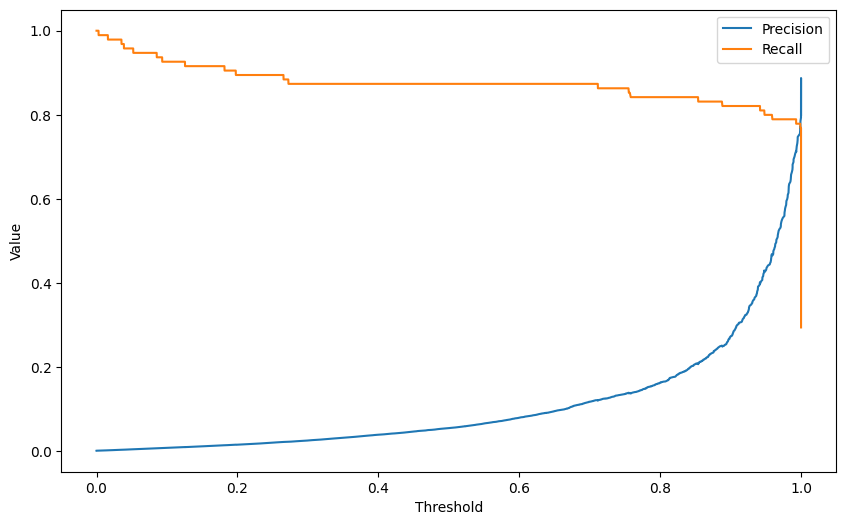

In [30]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize = (10, 6))
precision, recall, thresholds = precision_recall_curve(y_test, lr_probability_predictions[:, 1])
plt.plot(thresholds, precision[:-1], label = "Precision")
plt.plot(thresholds, recall[:-1], label = "Recall")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.legend()
plt.show()

### Figuring out the FP-cost and FN-Cost

In [31]:
X_test.index.equals(y_test.index) # Sanity check to see if the X_test and and y_test indexes line up correctly

True

In [34]:
# For every possible confidence cutoff, work out how much it would cost the
# merchant in real money — missed fraud (real ₹ lost) + false alarms (₹50 each
# for review/customer-friction cost). Whichever cutoff gives the lowest total
# is our best real-world choice, not just whichever looks best on a graph.

total_cost = []

for threshold in thresholds:
  y_pred = (lr_probability_predictions[:, 1] >= threshold)
  fn_mask = (y_test == 1) & (y_pred == 0)
  fp_mask = (y_test == 0) & (y_pred == 1)
  fn_cost = X_test.loc[fn_mask, 'Amount'].sum()
  fp_cost = 50 * fp_mask.sum()
  total = fn_cost + fp_cost
  total_cost.append(total)

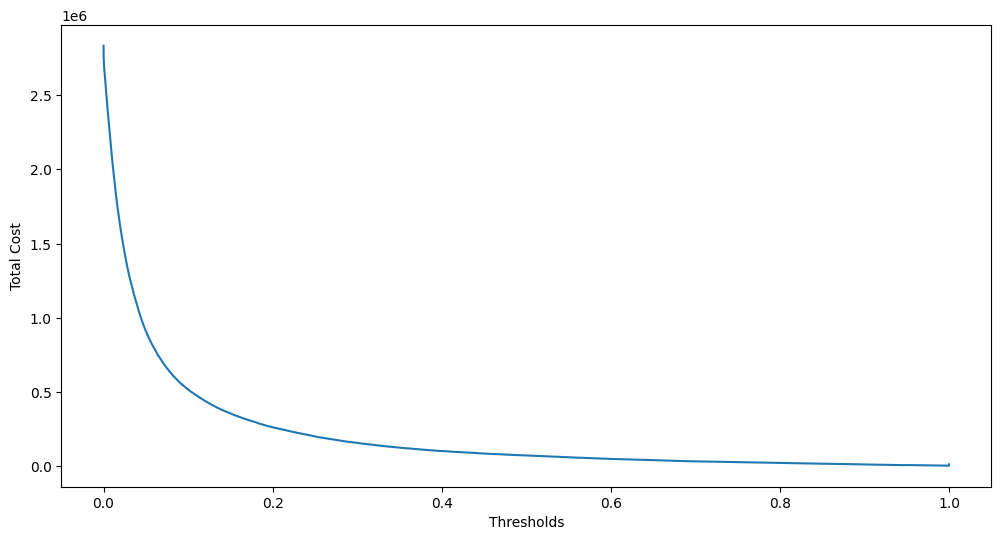

In [35]:
# plotting thresholds vs total_cost

plt.figure(figsize = (12, 6))
plt.plot(thresholds, total_cost)
plt.xlabel('Thresholds')
plt.ylabel("Total Cost")
plt.show()

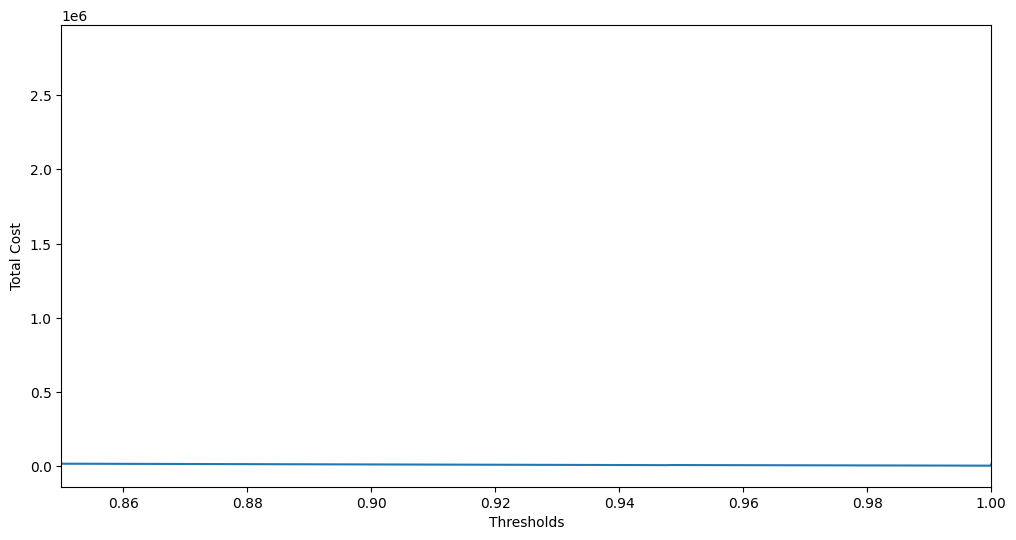

In [36]:
# plotting thresholds vs total_cost

plt.figure(figsize = (12, 6))
plt.plot(thresholds, total_cost)
plt.xlim(0.85, 1.0)
plt.xlabel('Thresholds')
plt.ylabel("Total Cost")
plt.show()

In [37]:
print(thresholds[np.argmin(total_cost)])

0.9999999591558791


## Is the "best" cutoff actually trustworthy?

The lowest-cost cutoff came out to ~0.9999999, which basically means
"only flag something if we're almost completely certain." Before trusting
that number, we need to check whether it's backed by real data or whether
it's just a fluke — very few transactions actually get scored near 1.0.

In [39]:
X_test.loc[y_test==1, 'Amount'].describe() # sanity check to see using a ₹ 50 cost for false positive is reliable

,Amount
count,95.000000
mean,155.434842
std,311.293511
min,0.000000
25%,1.000000
50%,12.310000
75%,109.615000
max,1809.680000


In [40]:
print((lr_probability_predictions[:,1] >= 0.9999999591558791).sum())

80


In [42]:
# Only look at a realistic range of cutoffs — avoids the unreliable
# extreme-confidence tail where very few transactions actually land.
mask = (thresholds >= 0.5) & (thresholds <= 0.95)
narrow_thresholds = thresholds[mask]
narrow_costs = np.array(total_cost)[mask]

best_threshold = narrow_thresholds[np.argmin(narrow_costs)]
print("Best threshold in realistic range:", best_threshold)

Best threshold in realistic range: 0.9478125526637202


In [45]:
print((lr_probability_predictions[:,1] >= best_threshold).sum())

179


In [51]:
mask = (thresholds >= 0.5) & (thresholds <= 0.90)
narrow_thresholds = thresholds[mask]
narrow_costs = np.array(total_cost)[mask]

best_threshold = narrow_thresholds[np.argmin(narrow_costs)]
print("Best threshold in realistic range:", best_threshold)

print((lr_probability_predictions[:,1] >= best_threshold).sum())

Best threshold in realistic range: 0.899816504040383
286


In [47]:
mask = (thresholds >= 0.5) & (thresholds <= 0.80)
narrow_thresholds = thresholds[mask]
narrow_costs = np.array(total_cost)[mask]

best_threshold = narrow_thresholds[np.argmin(narrow_costs)]
print("Best threshold in realistic range:", best_threshold)

print((lr_probability_predictions[:,1] >= best_threshold).sum())

Best threshold in realistic range: 0.7999146099846574
491


In [49]:
mask = (thresholds >= 0.5) & (thresholds <= 0.75)
narrow_thresholds = thresholds[mask]
narrow_costs = np.array(total_cost)[mask]

best_threshold = narrow_thresholds[np.argmin(narrow_costs)]
print("Best threshold in realistic range:", best_threshold)

print((lr_probability_predictions[:,1] >= best_threshold).sum())

Best threshold in realistic range: 0.7496932731452208
603


In [50]:
mask = (thresholds >= 0.5) & (thresholds <= 0.70)
narrow_thresholds = thresholds[mask]
narrow_costs = np.array(total_cost)[mask]

best_threshold = narrow_thresholds[np.argmin(narrow_costs)]
print("Best threshold in realistic range:", best_threshold)

print((lr_probability_predictions[:,1] >= best_threshold).sum())

Best threshold in realistic range: 0.6987739421449846
704
